In [71]:
import pandas as pd
from pathlib import Path

NOTEBOOK_DIR = Path().resolve()
base_file = NOTEBOOK_DIR / "all-MCU2.csv"
additional_file = NOTEBOOK_DIR / "gpt-5_sg_converted.csv"


def require_file(path: Path, missing_message: str) -> Path:
    if not path.exists():
        raise FileNotFoundError(f"{missing_message}: {path}")
    return path


def load_mcu_frames(base_csv: Path, additional_csv: Path):
    base_csv = require_file(base_csv, "Base CSV not found")
    additional_csv = require_file(additional_csv, "Additional CSV not found")

    df_base_local = pd.read_csv(base_csv).copy()
    df_additional_local = pd.read_csv(additional_csv).copy()

    df_base_local["source_file"] = base_csv.name
    df_additional_local["source_file"] = additional_csv.name

    merged = pd.concat([df_base_local, df_additional_local], ignore_index=True, sort=False)
    return df_base_local, df_additional_local, merged


def print_numeric_range(frame: pd.DataFrame, column: str, label: str, formatter):
    values = pd.to_numeric(frame.get(column), errors="coerce")
    if values.notna().any():
        print(f"- {label}: {formatter(values.min())} to {formatter(values.max())}")
    else:
        print(f"- {label}: N/A")


df_base, df_g5, df = load_mcu_frames(base_file, additional_file)

print(f"Loaded base rows: {len(df_base)}")
print(f"Loaded additional rows: {len(df_g5)}")
print(f"Merged rows: {len(df)}")

print("G5 data range (additional ArdSG set):")
print_numeric_range(df_g5, "latency", "latency (s)", lambda value: f"{value:.2f}")
print_numeric_range(df_g5, "total_tokens", "total_tokens", lambda value: f"{int(value)}")
print_numeric_range(df_g5, "total_cost", "total_cost (USD)", lambda value: f"{value:.6f}")

Loaded base rows: 630
Loaded additional rows: 30
Merged rows: 660
G5 data range (additional ArdSG set):
- latency (s): 154.13 to 370.24
- total_tokens: 11487 to 33629
- total_cost (USD): 0.086703 to 0.189412


In [72]:
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import to_rgba
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D
from matplotlib.patches import ConnectionPatch, PathPatch, Rectangle

required_cols = ("processor", "model", "status", "latency", "total_tokens")
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in df: {missing_cols}")

for col in ("processor", "model", "status"):
    df[col] = df[col].astype(str).str.strip().str.lower()

MODEL_LABELS = {
    "gpt-5": "G5",
    "gpt-4o": "G4o",
    "gpt-4o-mini": "G4o-m",
    "qwen32": "Qw32B",
    "qwen14": "Qw14B",
    "phi4": "Phi4",
    "codestral": "Co22B",
    "codestral-p": "Co22B-p",
}
PROCESSOR_LABELS = {
    "dp": "DP",
    "mc": "MC",
    "sg": "ArdSG",
    # "psg": "PyCPU-SG",
    # "tpusg": "PyTPU-SG",
}
MODEL_ORDER_PREF = list(MODEL_LABELS.values())
PROCESSOR_ORDER_PREF = ["dp", "mc", "sg"]
STATUS_ORDER = ["success", "failure"]

df["model_display"] = df["model"].map(MODEL_LABELS).fillna(df["model"])
print(MODEL_ORDER_PREF)

['G5', 'G4o', 'G4o-m', 'Qw32B', 'Qw14B', 'Phi4', 'Co22B', 'Co22B-p']


/var/folders/fk/pd_cb7_x7k3bl94y8nq4shgw0000gn/T/ipykernel_71698/2131941228.py:259: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
/var/folders/fk/pd_cb7_x7k3bl94y8nq4shgw0000gn/T/ipykernel_71698/2131941228.py:259: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
/var/folders/fk/pd_cb7_x7k3bl94y8nq4shgw0000gn/T/ipykernel_71698/2131941228.py:259: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
/var/folders/fk/pd_cb7_x7k3bl94y8nq4shgw0000gn/T/ipykernel_71698/2131941228.py:259: UserWarning: set_ticklabels() should only be used with a fixed number of tic

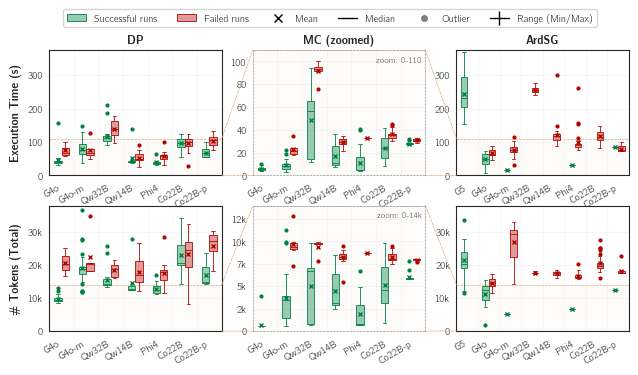

In [73]:

metrics = [
    {'col': 'latency', 'label': 'Execution Time (s)', 'fmt': None},
    {
        'col': 'total_tokens',
        'label': '# Tokens (Total)',
        'fmt': lambda x, _: f"{int(x/1000)}k" if x >= 1000 else f"{int(x)}"
    }
]

metric_limits = {
    'latency': (0, 375),
    'total_tokens': (0, 38000),
}

mc_metric_limits = {
    'latency': (0, 110),
    'total_tokens': (0, 14000),
}

# ==========================================
# 3. STYLE TOKENS (FONTS, SIZES, WEIGHTS, COLORS)
# ==========================================
# ── Font ─────────────────────────────────────────────────────────────────────
# Double column = 7.48 in; scale factor vs. original 18 in ≈ 0.42
# Elsevier: 7 pt normal, ≥6 pt subscripts [web:3]
FONT = {
    "family": "CMU Bright",
    "title_size": 8,           # was 14 → panel titles at 8 pt
    "title_weight": "bold",
    "label_size": 8,           # was 13 → y-axis labels at 8 pt
    "label_weight": "bold",
    "tick_size": 7,           # NEW
    "legend_size": 7,          # was 12 → 7 pt legend (Elsevier floor)
    "zoom_note_size": 6,       # was 9  → 6 pt min (subscript floor)
}

# ── Style ─────────────────────────────────────────────────────────────────────
STYLE = {
    "group_separator_linewidth": 0.4,  # was 0.6
    "group_separator_alpha": 0.35,
    "grid_linewidth": 0.4,             # was 0.6
    "grid_alpha": 0.5,
    "box_linewidth": 0.6,              # was 1.0
    "box_width": 0.6,                  # was 0.7 → narrower for compact axes
    "box_fill_alpha": 0.4,
    "mean_marker_size": 3,             # was 5
    "outlier_marker_size": 2,          # was 3
    "zoom_linewidth": 0.5,             # was 0.9
    "zoom_line_alpha": 0.9,
    "mc_spine_linewidth": 0.6,         # was 1.0
    "legend_columns": 6,               # keep 6; reduce to 4 if legend overflows
}

COLORS = {
    'status_success_fill': '#008142',
    'status_success_edge': '#008142',
    'status_failure_fill': '#B10600',
    'status_failure_edge': '#B10600',
    'zoom_band': '#F5F0E6',
    'zoom_line': '#D9A66A',
    'group_separator': '0.85',
    'grid': '0.88',
    'zoom_spine': '0.65',
    'zoom_note_text': '0.35',
    'mean_marker': 'black',
    'median_line': 'black',
    'outlier': 'gray',
}
 

STATUS_STYLES = {
    'success': {
        'facecolor': COLORS['status_success_fill'],
        'edgecolor': COLORS['status_success_edge'],
    },
    'failure': {
        'facecolor': COLORS['status_failure_fill'],
        'edgecolor': COLORS['status_failure_edge'],
    },
}
palette = {status: style['facecolor'] for status, style in STATUS_STYLES.items()}

# Processor-specific x-axis model order: only ArdSG keeps G5 tick.
MODEL_ORDER_BY_PROC = {
    'dp': [m for m in MODEL_ORDER_PREF if m != 'G5'],
    'mc': [m for m in MODEL_ORDER_PREF if m != 'G5'],
    'sg': MODEL_ORDER_PREF,
}

# ==========================================
# 4. PLOTTING
# ==========================================
sns.set_style('white')
plt.rcParams['font.family'] = FONT['family']
# Add this right after plt.rcParams["font.family"] = FONT["family"]
plt.rcParams.update({
    "font.size":         FONT["legend_size"],   # global fallback = 7 pt
    "axes.labelsize":    FONT["label_size"],     # 8 pt
    "axes.titlesize":    FONT["title_size"],     # 8 pt
    "xtick.labelsize":   7,                      # model name ticks
    "ytick.labelsize":   7,                      # value ticks
    "font.size":               FONT["tick_size"],       # global fallback
    "legend.fontsize":   FONT["legend_size"],    # 7 pt
    "legend.title_fontsize": FONT["label_size"], # 8 pt if legend has title
})

def patch_x_bounds(ax, patch):
    (x0, _), (x1, _) = ax.transData.inverted().transform(patch.get_extents().get_points())
    return min(x0, x1), max(x0, x1)


def status_for_box_center(box_center, n_models):
    nearest_model_idx = min(
        range(max(n_models, 1)),
        key=lambda idx: abs(box_center - idx)
    )
    return STATUS_ORDER[0] if box_center <= nearest_model_idx else STATUS_ORDER[1]


def style_boxplot_by_status(ax, n_models):
    box_patches = [patch for patch in ax.patches if isinstance(patch, PathPatch)]
    if not box_patches:
        return

    box_specs = []
    for patch in box_patches:
        x0, x1 = patch_x_bounds(ax, patch)
        box_center = (x0 + x1) / 2
        status = status_for_box_center(box_center, n_models)
        style = STATUS_STYLES[status]
        fill_rgba = to_rgba(style['facecolor'], STYLE['box_fill_alpha'])
        edge_color = style['edgecolor']

        patch.set_facecolor(fill_rgba)
        patch.set_edgecolor(edge_color)
        patch.set_linewidth(STYLE['box_linewidth'])

        box_specs.append({
            'center': box_center,
            'x0': x0,
            'x1': x1,
            'edgecolor': edge_color,
        })

    line_tol = STYLE['box_width'] * 0.08
    for line in ax.lines:
        xdata = []
        for value in line.get_xdata():
            try:
                numeric_value = float(value)
            except (TypeError, ValueError):
                continue
            if math.isfinite(numeric_value):
                xdata.append(numeric_value)

        if not xdata:
            continue

        x_min = min(xdata)
        x_max = max(xdata)
        x_center = sum(xdata) / len(xdata)

        matches = [
            spec
            for spec in box_specs
            if x_min >= spec['x0'] - line_tol and x_max <= spec['x1'] + line_tol
        ]
        if not matches:
            continue

        spec = min(matches, key=lambda item: abs(x_center - item['center']))
        line.set_color(spec['edgecolor'])
        line.set_markeredgecolor(spec['edgecolor'])
        line.set_markerfacecolor(spec['edgecolor'])


# fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 7), sharey=False)
# plt.subplots_adjust(top=0.915, hspace=0.13, wspace=0.1)

# Elsevier double column = 190 mm = 7.48 in [web:3]
# 2-row layout: height ≈ 7.48 / 1.8 ≈ 4.15 in (slightly taller than golden ratio
# to give the two subplot rows enough vertical breathing room)
ONE_MM = 1 / 25.4
fig, axes = plt.subplots(
    nrows=2, ncols=3,
    figsize=(190 * ONE_MM, 105 * ONE_MM),  # 7.48 × 4.13 in
    sharey=False,
)
plt.subplots_adjust(top=0.9, bottom=0.22, hspace=0.24, wspace=0.18)

for col_idx, proc in enumerate(PROCESSOR_ORDER_PREF):
    subset = df[df['processor'] == proc]

    if subset.empty:
        for row_idx in range(len(metrics)):
            axes[row_idx, col_idx].set_visible(False)
        continue

    plot_order = MODEL_ORDER_BY_PROC.get(proc, MODEL_ORDER_PREF)

    for row_idx, metric in enumerate(metrics):
        ax = axes[row_idx, col_idx]

        sns.boxplot(
            data=subset,
            x='model_display',
            y=metric['col'],
            hue='status',
            hue_order=STATUS_ORDER,
            order=plot_order,
            ax=ax,
            palette=palette,
            showmeans=True,
            meanprops={
                'marker': 'x',
                'markeredgecolor': COLORS['mean_marker'],
                'markersize': STYLE['mean_marker_size']
            },
            flierprops={
                'marker': 'o',
                'markersize': STYLE['outlier_marker_size'],
                'markerfacecolor': COLORS['outlier'],
                'markeredgecolor': COLORS['outlier']
            },
            width=STYLE['box_width'],
            linewidth=STYLE['box_linewidth']
        )
        style_boxplot_by_status(ax, len(plot_order))

        for xpos in np.arange(len(plot_order) - 1) + 0.5:
            ax.axvline(
                x=xpos,
                color=COLORS['group_separator'],
                linewidth=STYLE['group_separator_linewidth'],
                alpha=STYLE['group_separator_alpha'],
                zorder=0
            )

        if ax.get_legend():
            ax.get_legend().remove()
        ax.set_xlabel('')
        ax.grid(
            axis='y',
            color=COLORS['grid'],
            linewidth=STYLE['grid_linewidth'],
            linestyle='-',
            alpha=STYLE['grid_alpha']
        )

        ax.set_ylabel(
            metric['label'] if col_idx == 0 else '',
            fontweight=FONT['label_weight'],
            fontsize=FONT['label_size']
        )
        # ax.tick_params(axis='y', pad=0)
        ax.tick_params(axis="y", labelsize=FONT["tick_size"], pad=1)
        ax.tick_params(axis="x", labelsize=FONT["tick_size"], pad=2)
        
        ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")

    
        if row_idx == 0:
            title = PROCESSOR_LABELS.get(proc, proc)
            if proc == 'mc':
                title += ' (zoomed)'
            ax.set_title(
                title,
                fontsize=FONT['title_size'],
                weight=FONT['title_weight'],
                pad=5
            )

        if metric['fmt']:
            ax.yaxis.set_major_formatter(FuncFormatter(metric['fmt']))

        if proc == 'mc' and metric['col'] in mc_metric_limits:
            y0, y1 = mc_metric_limits[metric['col']]
            ax.set_ylim(y0, y1)

            for spine in ax.spines.values():
                spine.set_linestyle((0, (2, 2)))
                spine.set_linewidth(STYLE['mc_spine_linewidth'])
                spine.set_color(COLORS['zoom_spine'])

            range_label = (
                f"{int(y0)}-{int(y1/1000)}k"
                if metric['col'] == 'total_tokens'
                else f"{int(y0)}-{int(y1)}"
            )
            ax.text(
                0.98,
                0.95,
                f"zoom: {range_label}",
                transform=ax.transAxes,
                ha='right',
                va='top',
                fontsize=FONT['zoom_note_size'],
                color=COLORS['zoom_note_text']
            )
        elif metric['col'] in metric_limits:
            ax.set_ylim(*metric_limits[metric['col']])

# ==========================================
# 5. ZOOM-LINK INDICATORS (MC <-> DP/ArdSG)
# ==========================================
for row_idx, metric in enumerate(metrics):
    metric_col = metric['col']
    y0, y1 = mc_metric_limits[metric_col]

    dp_ax = axes[row_idx, 0]
    mc_ax = axes[row_idx, 1]
    sg_ax = axes[row_idx, 2]

    dp_ax.axhspan(y0, y1, color=COLORS['zoom_band'], alpha=0.20, zorder=0)
    sg_ax.axhspan(y0, y1, color=COLORS['zoom_band'], alpha=0.20, zorder=0)

    mc_ax.set_facecolor(COLORS['zoom_band'])
    mc_ax.patch.set_alpha(0.20)

    for ax in [dp_ax, mc_ax, sg_ax]:
        ax.axhline(
            y=y0,
            color=COLORS['zoom_line'],
            linewidth=STYLE['zoom_linewidth'],
            linestyle='--',
            alpha=STYLE['zoom_line_alpha'],
            zorder=0
        )
        ax.axhline(
            y=y1,
            color=COLORS['zoom_line'],
            linewidth=STYLE['zoom_linewidth'],
            linestyle='--',
            alpha=STYLE['zoom_line_alpha'],
            zorder=0
        )

    for src_ax, dst_ax in [(dp_ax, mc_ax), (mc_ax, sg_ax)]:
        for y in (y0, y1):
            fig.add_artist(ConnectionPatch(
                xyA=(1.0, y), coordsA=src_ax.get_yaxis_transform(),
                xyB=(0.0, y), coordsB=dst_ax.get_yaxis_transform(),
                color=COLORS['zoom_line'],
                linewidth=STYLE['zoom_linewidth'],
                linestyle='--',
                alpha=STYLE['zoom_line_alpha']
            ))

# ==========================================
# 6. CUSTOM LEGEND
# ==========================================
legend_elements = [
    Rectangle(
        (0, 0), 1, 1,
        facecolor=to_rgba(COLORS['status_success_fill'], STYLE['box_fill_alpha']),
        edgecolor=COLORS['status_success_edge'],
        linewidth=STYLE['box_linewidth'],
        label='Successful runs'
    ),
    Rectangle(
        (0, 0), 1, 1,
        facecolor=to_rgba(COLORS['status_failure_fill'], STYLE['box_fill_alpha']),
        edgecolor=COLORS['status_failure_edge'],
        linewidth=STYLE['box_linewidth'],
        label='Failed runs'
    ),
    Line2D([0], [0], color=COLORS['mean_marker'], marker='x', linestyle='None', markersize=6, label='Mean'),
    Line2D([0], [0], color=COLORS['median_line'], linewidth=1, linestyle='-', label='Median'),
    Line2D([0], [0], color=COLORS['outlier'], marker='o', linestyle='None', markersize=4, label='Outlier'),
    Line2D([0], [0], color=COLORS['median_line'], linewidth=1, linestyle='-', marker='|', markersize=10, label='Range (Min/Max)')
]

fig.legend(
    handles=legend_elements,
    loc='upper center',
    ncol=STYLE['legend_columns'],
    bbox_to_anchor=(0.5, 1.01),
    fontsize=FONT['legend_size'],
    frameon=True
)
file_path = 'figs/box_MCU_with-g5'

plt.savefig(file_path+'.pdf', dpi=500, bbox_inches='tight')
plt.savefig(file_path+'.png', dpi=500, bbox_inches='tight')
plt.show()


In [74]:
from pathlib import Path
import pandas as pd
import numpy as np

DATA_DIR = Path().resolve()
base_csv_file = DATA_DIR / "all-MCU2.csv"
additional_csv_file = DATA_DIR / "gpt-5_sg_converted.csv"


def require_csv(path: Path, missing_message: str) -> Path:
    if not path.exists():
        raise FileNotFoundError(f"{missing_message}: {path}")
    return path


def read_with_source(path: Path) -> pd.DataFrame:
    frame = pd.read_csv(path).copy()
    frame["source_file"] = path.name
    return frame


def ensure_numeric_column(frame: pd.DataFrame, column: str):
    if column not in frame.columns:
        frame[column] = np.nan
    frame[column] = pd.to_numeric(frame[column], errors="coerce")


MODEL_LABELS = {
    "gpt-5": "G5",
    "gpt-4o": "G4o",
    "gpt-4o-mini": "G4o-m",
    "phi4": "Phi4",
    "qwen32": "Qw32B",
    "qwen14": "Qw14B",
    "codestral": "Co22B",
    "codestral-p": "Co22B-p",
    "gemma3": "Ge3",
}
PROCESSOR_LABELS = {
    "dp": "DP",
    "mc": "MC",
    "sg": "ArdSG",
    "psg": "PyCPU-SG",
    "tpusg": "PyTPU-SG",
}

MODEL_ORDER_PREF = list(MODEL_LABELS.keys())
PROCESSOR_ORDER_PREF = list(PROCESSOR_LABELS.keys())
required_cols = {"status", "latency", "processor", "model"}

base_csv_file = require_csv(base_csv_file, "Base CSV file not found")
additional_csv_file = require_csv(additional_csv_file, "Additional CSV file not found")

df_base = read_with_source(base_csv_file)
df_additional = read_with_source(additional_csv_file)

# Merge base + additional rows (asymmetric G5-only ArdSG additions come from the second file)
df = pd.concat([df_base, df_additional], ignore_index=True, sort=False)
df.columns = df.columns.str.strip()

missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Merged dataframe is missing required columns: {sorted(missing)}")

df = df.copy()
df["status"] = df["status"].astype(str).str.strip().str.lower()
df["status_group"] = np.where(df["status"] == "success", "success", "failure")
df["processor_std"] = df["processor"].astype(str).str.strip().str.lower()
df["model_std"] = df["model"].astype(str).str.strip().str.lower()

for numeric_col in ("latency", "total_cost", "total_tokens"):
    ensure_numeric_column(df, numeric_col)

keep_cols = [
    "model_std",
    "processor_std",
    "status_group",
    "latency",
    "total_cost",
    "total_tokens",
    "source_file",
    "model",
    "processor",
    "status",
]
df = df[keep_cols]

# Sanity checks for added G5-ArdSG data
g5_sg_mask = (df["model_std"] == "gpt-5") & (df["processor_std"] == "sg")
g5_sg_rows = df[g5_sg_mask]
g5_non_sg_rows = df[(df["model_std"] == "gpt-5") & (df["processor_std"] != "sg")]
g5_failures = g5_sg_rows[g5_sg_rows["status_group"] == "failure"]

if g5_sg_rows.empty:
    raise ValueError("No merged rows found for model='gpt-5' and processor='sg'.")
if len(g5_non_sg_rows) > 0:
    print(f"Warning: Found {len(g5_non_sg_rows)} G5 rows outside ArdSG; they will not be used for asymmetric additions.")
if len(g5_failures) > 0:
    print(f"Warning: Found {len(g5_failures)} G5 ArdSG failure rows; expected zero by spec.")

print(f"Loaded base rows: {len(df_base)}")
print(f"Loaded additional rows: {len(df_additional)}")
print(f"Merged rows: {len(df)}")
print(f"G5 ArdSG rows: {len(g5_sg_rows)}")

Loaded base rows: 630
Loaded additional rows: 30
Merged rows: 660
G5 ArdSG rows: 30


In [75]:
import pprint

models_present = list(df["model_std"].unique())
processors_present = list(df["processor_std"].unique())

model_order = [m for m in MODEL_ORDER_PREF if m in models_present] + [
    m for m in models_present if m not in MODEL_ORDER_PREF
]
processor_order = [p for p in PROCESSOR_ORDER_PREF if p in processors_present] + [
    p for p in processors_present if p not in PROCESSOR_ORDER_PREF
]

pivot_data = (
    df.groupby(["model_std", "processor_std", "status_group"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["success", "failure"], fill_value=0)
)

success_rate_dict = {}
for (model, processor), row in pivot_data.iterrows():
    success_count = int(row["success"])
    failure_count = int(row["failure"])
    total = success_count + failure_count
    success_rate_dict[(model, processor)] = {
        "success_count": success_count,
        "failure_count": failure_count,
        "total": total,
        "success_rate": (success_count / total) if total else 0.0,
    }

print("Success rate summary (fraction):")
pprint.pprint(success_rate_dict)


def processor_metric_means(frame: pd.DataFrame, metric: str):
    if frame.empty or metric not in frame.columns:
        return {p: 0.0 for p in processor_order}
    return (
        frame.groupby("processor_std")[metric]
        .mean()
        .reindex(processor_order)
        .fillna(0.0)
        .to_dict()
    )


def safe_mean(frame: pd.DataFrame, metric: str) -> float:
    if frame.empty or frame[metric].dropna().empty:
        return 0.0
    return float(frame[metric].mean())


def build_model_dict(model_key: str):
    subset = df[df["model_std"] == model_key]
    if subset.empty:
        return {"latency": {}, "cost": {}}

    success_frame = subset[subset["status_group"] == "success"]
    failure_frame = subset[subset["status_group"] != "success"]

    return {
        "latency": {
            **processor_metric_means(success_frame, "latency"),
            "total": safe_mean(success_frame, "latency"),
            "total_x": safe_mean(failure_frame, "latency"),
        },
        "cost": {
            **processor_metric_means(success_frame, "total_cost"),
            "total": safe_mean(success_frame, "total_cost"),
            "total_x": safe_mean(failure_frame, "total_cost"),
        },
    }


models_by_volume = df["model_std"].value_counts().index.tolist()
gpt_models = [m for m in models_by_volume if "gpt" in m and m != "gpt-5"]
if not gpt_models:
    raise ValueError("No non-G5 GPT models found for base comparison plot.")

primary_model = gpt_models[0]
secondary_model = gpt_models[1] if len(gpt_models) > 1 else None

primary_stats = build_model_dict(primary_model)
secondary_stats = build_model_dict(secondary_model) if secondary_model else None

# Targeted asymmetric add-on: G5 in ArdSG success only
g5_runs_df = df[df["model_std"] == "gpt-5"]
g5_sg_success_df = df[
    (df["model_std"] == "gpt-5")
    & (df["processor_std"] == "sg")
    & (df["status_group"] == "success")
]
g4o_success_df = df[
    (df["model_std"] == "gpt-4o")
    & (df["status_group"] == "success")
]
g5_sg_time = float(g5_sg_success_df["latency"].mean()) if not g5_sg_success_df.empty else np.nan
g5_sg_cost = float(g5_sg_success_df["total_cost"].mean()) if not g5_sg_success_df.empty else np.nan
g5_mean_time = float(g5_runs_df["latency"].mean()) if not g5_runs_df.empty else np.nan
g5_mean_tokens = float(g5_runs_df["total_tokens"].mean()) if not g5_runs_df.empty else np.nan
g4o_success_mean_time = float(g4o_success_df["latency"].mean()) if not g4o_success_df.empty else np.nan
g4o_success_mean_tokens = float(g4o_success_df["total_tokens"].mean()) if not g4o_success_df.empty else np.nan

COST_SCALE = 100
primary_stats["cost"] = {k: (v or 0) * COST_SCALE for k, v in primary_stats["cost"].items()}
if secondary_stats:
    secondary_stats["cost"] = {k: (v or 0) * COST_SCALE for k, v in secondary_stats["cost"].items()}
g5_sg_cost_cents = g5_sg_cost * COST_SCALE if pd.notna(g5_sg_cost) else np.nan

print("\n" + "=" * 80)
print("Primary model:", MODEL_LABELS.get(primary_model, primary_model))
print("=" * 80)
pprint.pprint(primary_stats)
if secondary_stats:
    print("\n" + "=" * 80)
    print("Secondary model:", MODEL_LABELS.get(secondary_model, secondary_model))
    print("=" * 80)
    pprint.pprint(secondary_stats)

print("\nAsymmetric G5 add-on (ArdSG success only):")
print({"g5_sg_time": g5_sg_time, "g5_sg_cost_cents": g5_sg_cost_cents})

print("\nFooter summary metrics:")
pprint.pprint(
    {
        "g5_runs": {
            "mean_execution_time_s": g5_mean_time,
            "mean_total_tokens": g5_mean_tokens,
        },
        "g4o_successful_runs": {
            "mean_execution_time_s": g4o_success_mean_time,
            "mean_total_tokens": g4o_success_mean_tokens,
        },
    }
)

Success rate summary (fraction):
{('codestral', 'dp'): {'failure_count': 19,
                       'success_count': 11,
                       'success_rate': 0.36666666666666664,
                       'total': 30},
 ('codestral', 'mc'): {'failure_count': 14,
                       'success_count': 16,
                       'success_rate': 0.5333333333333333,
                       'total': 30},
 ('codestral', 'sg'): {'failure_count': 30,
                       'success_count': 0,
                       'success_rate': 0.0,
                       'total': 30},
 ('codestral-p', 'dp'): {'failure_count': 12,
                         'success_count': 18,
                         'success_rate': 0.6,
                         'total': 30},
 ('codestral-p', 'mc'): {'failure_count': 6,
                         'success_count': 24,
                         'success_rate': 0.8,
                         'total': 30},
 ('codestral-p', 'sg'): {'failure_count': 29,
                         'succe

figure size: 8.0 x 4.5


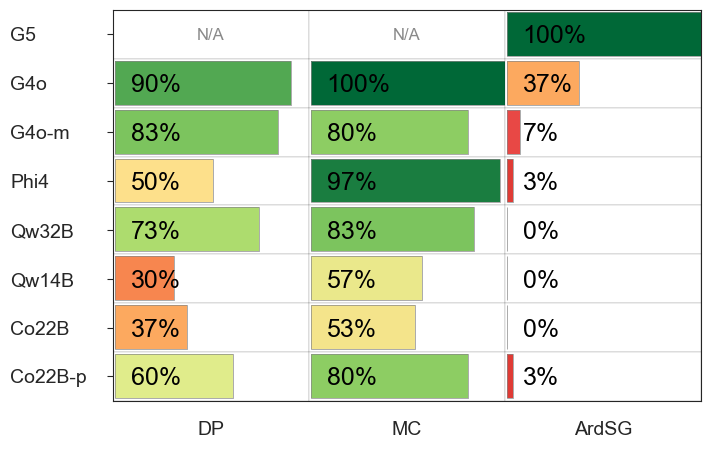

In [76]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap

# Build dataframe again to stay in sync even if previous cell is skipped.
heatmap_df = pd.DataFrame(
    [
        {
            "model": MODEL_LABELS.get(model, model),
            "processor": processor,
            "success_rate": data["success_rate"] * 100 if data["success_rate"] <= 1 else data["success_rate"],
        }
        for (model, processor), data in success_rate_dict.items()
    ]
)

heatmap_df = heatmap_df.pivot(index="model", columns="processor", values="success_rate")
heatmap_df = heatmap_df.reindex(
    index=[MODEL_LABELS.get(model, model) for model in model_order],
    columns=processor_order,
)

plt.rcParams["font.family"] = "Arial"

fig_width, fig_height = 8, 4.5
print(f"figure size: {fig_width:.1f} x {fig_height:.1f}")
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

cmap = LinearSegmentedColormap.from_list(
    "custom",
    [
        "#D73027",
        "#F65D5F",
        "#F46D43",
        "#FDAE61",
        "#FEE08B",
        "#D9EF8B",
        "#A6D96A",
        "#68BA59",
        "#006837",
    ],
    N=256,
)

ax.set_xlim(0, len(heatmap_df.columns))
ax.set_ylim(0, len(heatmap_df.index))
ax.invert_yaxis()

bar_height_ratio = 0.9
gap = 0
null_symbol = "N/A"


def draw_cell_background(x_idx: int, y_idx: int):
    rect = mpatches.Rectangle(
        (x_idx + gap / 2, y_idx + gap / 2),
        1 - gap,
        1 - gap,
        facecolor="white",
        edgecolor="black",
        linewidth=0.1,
    )
    ax.add_patch(rect)


def draw_success_bar(x_idx: int, y_idx: int, value: float):
    x_offset = 0.01
    y_offset = (1 - bar_height_ratio) / 2 - 0.01
    bar_width = value / 100

    bar_rect = mpatches.Rectangle(
        (x_idx + x_offset, y_idx + y_offset),
        bar_width,
        bar_height_ratio,
        facecolor=cmap(value / 100),
        edgecolor="none",
        linewidth=0,
    )
    ax.add_patch(bar_rect)

    bar_border = mpatches.Rectangle(
        (x_idx + x_offset, y_idx + y_offset),
        bar_width,
        bar_height_ratio,
        facecolor="none",
        edgecolor="#888888",
        linewidth=0.5,
    )
    ax.add_patch(bar_border)

    ax.text(
        x_idx + 0.09,
        y_idx + 0.55,
        f"{value:.0f}%",
        ha="left",
        va="center",
        fontsize=18,
        weight="regular",
        color="black",
    )


def draw_missing_marker(x_idx: int, y_idx: int):
    # Explicit symbol for missing stage-model pair (null, not 0%).
    ax.text(
        x_idx + 0.5,
        y_idx + 0.52,
        null_symbol,
        ha="center",
        va="center",
        fontsize=12,
        weight="regular",
        color="#8a8a8a",
    )


for y_idx, model in enumerate(heatmap_df.index):
    for x_idx, processor in enumerate(heatmap_df.columns):
        value = heatmap_df.loc[model, processor]
        draw_cell_background(x_idx, y_idx)

        if pd.notna(value):
            draw_success_bar(x_idx, y_idx, value)
        else:
            draw_missing_marker(x_idx, y_idx)

ax.set_xticks([i + 0.5 for i in range(len(heatmap_df.columns))])
ax.set_yticks([i + 0.5 for i in range(len(heatmap_df.index))])
ax.set_xticklabels(
    [PROCESSOR_LABELS.get(col, col) for col in heatmap_df.columns],
    fontsize=14,
    weight="regular",
)
ax.set_yticklabels(heatmap_df.index, fontsize=14)
for label in ax.get_yticklabels():
    label.set_horizontalalignment("left")
    label.set_x(-0.18)

# Explicitly restore left y-axis ticks after seaborn white-style settings.
ax.tick_params(axis="y", which="both", left=True, length=4, width=0.8, pad=-6)
ax.tick_params(axis="x", which="both", pad=11)

# Keep the full heatmap frame visible.
for side in ("left", "top", "right", "bottom"):
    ax.spines[side].set_visible(True)

# ax.set_xlabel("Stages", fontsize=13, weight="regular", labelpad=5, color="gray", x=0.4)
# ax.set_ylabel("Models", fontsize=13, weight="regular", labelpad=5, color="gray", x=0.03)

plt.subplots_adjust(left=0.22)
plt.tight_layout(rect=[0.12, 0, 1, 1])
plt.savefig("figs/with-additional-g5-success-rate_MCU.pdf", dpi=300, bbox_inches="tight")

plt.show()

Figure size: 3.54 x 3.5


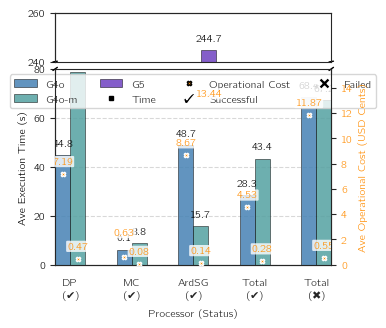


Plot saved as 'figs/g5-g4o-g4om_mcu_comparison.pdf' with dpi=500 and bbox_inches='tight'


In [77]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator

COLORS = {
    "primary_bar": "steelblue",
    "secondary_bar": "#54a1a1",
    "g5_bar": "#6f42c1",
    "cost_annotation": "darkorange",
    "background": "#ffffff",
    "text": "#000000",
    "time_axis": "black",
    "grid": "gray",
    "cost_marker_edge": "white",
    "cost_label_box": "white",
    "cost_label_box_edge": "none",
    "legend_cost_marker_edge": "black",
}
COLORS["cost_axis"] = COLORS["cost_annotation"]
COLORS["legend_cost_marker_face"] = COLORS["cost_annotation"]

# ── Font ─────────────────────────────────────────────────────────────────────
# Elsevier spec: 7 pt normal text, ≥6 pt subscripts, Arial/Helvetica [web:3][web:19]
FONT = {
    "family": "CMU Bright",
    "base": 8,              # was 13 → 8 pt = standard label size at print dimensions
    "weight_regular": "regular",
    "label_weight": "regular",
    "ylabel_plus": 0,       # axis labels at 9 pt (8+1) — slightly bolder than ticks
    "xtick_plus": 0,        # x-tick labels at 8 pt
    "cost_label_minus": 0,  # cost annotations at 8 pt (≥7 pt min)
    "legend_minus": 0,      # legend text at 7 pt (8-1)
}
 

plt.rcParams["font.family"] = FONT["family"]

# ── Figure ────────────────────────────────────────────────────────────────────
# Elsevier double column = 190 mm = 7.48 in [web:3][web:19]
# Height uses golden ratio (~1.618): 7.48 / 1.618 ≈ 4.62 in base
FIGURE = {
    "min_width": 3.54,              # was 7.48 → single column = 90 mm
    "width_per_category": 0.40,     # was 0.55 → much tighter per category
    "base_height": 3.20,            # was 3.8 → shorter absolute height
    "height_per_category": 0.06,    # was 0.08
    "marker_size_base": 3,          # was 4 → smaller markers
    "marker_size_width_scale": 0.3, # was 0.2 → scale with narrower width
    "marker_size_width_offset": 2.5,# was 5.0
}
 

# ── Bars ──────────────────────────────────────────────────────────────────────
BARS = {
    "max_width": 0.22,      # was 0.30 → narrower bars for compact layout
    "total_span": 0.65,     # was 0.75
    "edgecolor": "black",
    "linewidth": 0.4,       # was 0.5 → thinnest viable edge at small size
    "alpha": 0.85,
    "zorder": 3,
}


AXIS = {
    "time_label": "Ave Execution Time (s)",
    "cost_label": "Ave Operational Cost (USD Cents)",
    "xlabel": "Processor (Status)",
    "x_tick_pad": 10,
    "grid_linestyle": "--",
    "grid_alpha": 0.3,
    "grid_zorder": 0,
    "time_nbins": 5,
    "break_tick_step": 20.0,
}

COST_ANNOTATION = {
    "marker": "X",
    "marker_edge_width": 1,
    "marker_zorder": 5,
    "time_label_offset_ratio": 0.01,
    "cost_label_default_offset_ratio": 0.04,
    "text_height_ratio": 0.08,
    "overlap_margin_ratio": 1.2,
    "horizontal_threshold_width_ratio": 1.5,
    "max_attempts": 10,
    "max_label_height_ratio": 0.85,
    "cost_box_style": "round,pad=0.1",
    "cost_box_alpha": 0.8,
    "cost_text_format": "{cost:.2f}",
    "time_text_format": "{time:.1f}",
    "cost_text_ha": "center",
    "cost_text_va": "bottom",
    "time_text_ha": "center",
    "time_text_va": "bottom",
}

LEGEND = {
    "loc": "upper center",
    "frameon": True,
    "fancybox": True,
    "shadow": False,
    "ncol": 4,
    "time_label": "Time",
    "cost_label": "Operational Cost",
    "success_label": "Successful",
    "fail_label": "Failed",
    "success_marker": "$✔$",
    "fail_marker": "$✖$",
}

keys = [*processor_order, "total", "total_x"]
categories = [f"{PROCESSOR_LABELS.get(p, p)}\n($✔$)" for p in processor_order] + ["Total\n($✔$)", "Total\n($✖$)"]

# Force model ordering in bars/legend: GPT-4o first, GPT-4o-mini second.
model_stats_by_key = {
    model: stats
    for model, stats in ((primary_model, primary_stats), (secondary_model, secondary_stats))
    if model and stats
}
ordered_model_keys = [m for m in ("gpt-4o", "gpt-4o-mini") if m in model_stats_by_key]
ordered_model_keys += [m for m in model_stats_by_key if m not in ordered_model_keys]

if not ordered_model_keys:
    raise ValueError("No model stats available for the cost/time comparison plot.")

first_model = ordered_model_keys[0]
first_stats = model_stats_by_key[first_model]
first_label = MODEL_LABELS.get(first_model, first_model)

second_model = ordered_model_keys[1] if len(ordered_model_keys) > 1 else None
second_stats = model_stats_by_key.get(second_model) if second_model else None
second_label = MODEL_LABELS.get(second_model, second_model) if second_model else None


def extract_metrics(stats, metric_keys):
    return (
        np.array([stats["latency"].get(key, 0) for key in metric_keys]),
        np.array([stats["cost"].get(key, 0) for key in metric_keys]),
    )


times_first, costs_first = extract_metrics(first_stats, keys)
if second_stats:
    times_second, costs_second = extract_metrics(second_stats, keys)
else:
    times_second = np.zeros_like(times_first)
    costs_second = np.zeros_like(costs_first)

num_categories = len(categories)
series_count = len(ordered_model_keys)
fig_width = max(FIGURE["min_width"], num_categories * FIGURE["width_per_category"])
fig_height = FIGURE["base_height"] + FIGURE["height_per_category"] * num_categories
print(f"Figure size: {fig_width} x {fig_height}")

font_base = FONT["base"]
marker_size = FIGURE["marker_size_base"] + (fig_width - FIGURE["marker_size_width_offset"]) * FIGURE["marker_size_width_scale"]


def nice_limit(value, pct_pad, step):
    return float(np.ceil(max(value, step) * (1 + pct_pad) / step) * step)


max_time_candidates = [times_first.max(), times_second.max()]
max_cost_candidates = [costs_first.max(), costs_second.max()]
if pd.notna(g5_sg_time):
    max_time_candidates.append(g5_sg_time)
if pd.notna(g5_sg_cost_cents):
    max_cost_candidates.append(g5_sg_cost_cents)

max_time = np.nanmax(max_time_candidates)
max_cost = np.nanmax(max_cost_candidates)
y_max_time = nice_limit(max_time, 0.2, 5)
y_max_cost = nice_limit(max_cost, 0.15, 0.5)

# Broken axis configuration for left y-axis (time).
y_break_low = 80.0
y_break_high = 240.0
y_top_cap = 260.0
tick_step = AXIS["break_tick_step"]
use_broken_axis = y_max_time > y_break_high

x = np.arange(num_categories) * 0.9
width = min(BARS["max_width"], BARS["total_span"] / max(series_count, 1))
offset = width / 2 if series_count == 2 else 0.0

if use_broken_axis:
    top_range = max(y_top_cap - y_break_high, tick_step)
    bottom_range = max(y_break_low, tick_step)

    fig = plt.figure(figsize=(fig_width, fig_height))
    gs = fig.add_gridspec(2, 1, height_ratios=[top_range, bottom_range], hspace=0.06)
    ax_top = fig.add_subplot(gs[0])
    ax_bot = fig.add_subplot(gs[1], sharex=ax_top)

    ax_bot.set_facecolor(COLORS["background"])
    ax_bot.grid(
        axis="y",
        linestyle=AXIS["grid_linestyle"],
        alpha=AXIS["grid_alpha"],
        color=COLORS["grid"],
        zorder=AXIS["grid_zorder"],
    )
    ax_top.set_facecolor(COLORS["background"])
    ax_top.grid(False)

    ax_top.set_ylim(y_break_high, y_top_cap)
    ax_bot.set_ylim(0, y_break_low)

    ax_bot.set_yticks(np.arange(0, y_break_low + 0.1, tick_step))
    ax_top.set_yticks(np.array([y_break_high, y_top_cap]))

    ax_top.spines["bottom"].set_visible(False)
    ax_bot.spines["top"].set_visible(False)
    ax_top.tick_params(labelbottom=False, bottom=False)

    d = 0.008
    kwargs = dict(transform=ax_top.transAxes, color="k", clip_on=False, linewidth=1.0)
    ax_top.plot((-d, +d), (-d, +d), **kwargs)
    ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)
    kwargs.update(transform=ax_bot.transAxes)
    ax_bot.plot((-d, +d), (1 - d, 1 + d), **kwargs)
    ax_bot.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

    # Keep right axis as a single continuous scale.
    ax2_top = ax_top.twinx()
    ax2_top.set_yticks([])
    ax2_top.spines["right"].set_visible(False)

    ax2_bot = ax_bot.twinx()
    ax2_bot.set_ylim(0, y_max_cost)

    primary_axes = (ax_top, ax_bot)
else:
    fig, ax_bot = plt.subplots(figsize=(fig_width, fig_height))
    ax_bot.set_facecolor(COLORS["background"])
    ax_bot.grid(
        axis="y",
        linestyle=AXIS["grid_linestyle"],
        alpha=AXIS["grid_alpha"],
        color=COLORS["grid"],
        zorder=AXIS["grid_zorder"],
    )
    ax_bot.set_ylim(0, y_max_time)

    ax2_bot = ax_bot.twinx()
    ax2_bot.set_ylim(0, y_max_cost)
    primary_axes = (ax_bot,)

fig.patch.set_facecolor(COLORS["background"])


def draw_series_on_axes(y_values, x_positions, color, label, draw_label=True):
    bars_refs = []
    for idx, axis in enumerate(primary_axes):
        plotted_values = y_values
        if use_broken_axis:
            if axis is ax_bot:
                plotted_values = np.where(y_values <= y_break_low, y_values, np.nan)
            else:
                plotted_values = np.where(y_values >= y_break_high, y_values, np.nan)

        bars = axis.bar(
            x_positions,
            plotted_values,
            width,
            color=color,
            edgecolor=BARS["edgecolor"],
            linewidth=BARS["linewidth"],
            alpha=BARS["alpha"],
            zorder=BARS["zorder"],
            label=label if (idx == len(primary_axes) - 1 and draw_label) else "_nolegend_",
        )
        if idx == len(primary_axes) - 1:
            bars_refs = bars
    return bars_refs


bars_first = draw_series_on_axes(times_first, x - offset, COLORS["primary_bar"], first_label)
bars_second = (
    draw_series_on_axes(times_second, x + offset, COLORS["secondary_bar"], second_label)
    if second_stats
    else []
)

# Asymmetric add-on: single G5 bar in ArdSG-success cluster only.
g5_bars = []
g5_times = np.array([])
g5_costs = np.array([])
if "sg" in processor_order and pd.notna(g5_sg_time):
    sg_idx = processor_order.index("sg")
    g5_x = x[sg_idx] + (width * 1.05)
    g5_bars = draw_series_on_axes(
        np.array([g5_sg_time]),
        np.array([g5_x]),
        COLORS["g5_bar"],
        MODEL_LABELS.get("gpt-5", "gpt-5"),
    )
    g5_times = np.array([g5_sg_time])
    g5_costs = np.array([g5_sg_cost_cents])
else:
    print("Warning: Skipped G5 single-bar add-on because ArdSG or G5 success metric is unavailable.")

ax_main = primary_axes[-1]
ax_main.set_ylabel(
    AXIS["time_label"],
    fontsize=font_base + FONT["ylabel_plus"],
    fontweight=FONT["weight_regular"],
    color=COLORS["time_axis"],
)
ax_main.set_xticks(x)
ax_main.set_xticklabels(
    categories,
    fontsize=font_base + FONT["xtick_plus"],
    fontweight=FONT["weight_regular"],
)
ax_main.tick_params(axis="y", labelsize=font_base, labelcolor=COLORS["time_axis"])
ax_main.tick_params(axis="x", length=0, pad=AXIS["x_tick_pad"])

for axis in primary_axes:
    axis.tick_params(axis="y", labelsize=font_base, labelcolor=COLORS["time_axis"])
    if not use_broken_axis:
        axis.yaxis.set_major_locator(MaxNLocator(nbins=AXIS["time_nbins"]))
    axis.set_xlim(-width, x[-1] + width)

ax_cost = ax2_bot
ax_cost.set_ylabel(
    AXIS["cost_label"],
    fontsize=font_base + FONT["ylabel_plus"],
    fontweight=FONT["weight_regular"],
    color=COLORS["cost_axis"],
)
ax_cost.tick_params(axis="y", labelsize=font_base, labelcolor=COLORS["cost_axis"])

placed_cost_labels = []


def visible_y_for_time(y):
    if not use_broken_axis:
        return y
    if y_break_low < y < y_break_high:
        return y_break_low - 0.8
    if y > y_top_cap:
        return y_top_cap - 0.8
    return y


def axis_for_time(y):
    if not use_broken_axis:
        return primary_axes[0]
    return ax_bot if y <= y_break_low else ax_top


def add_annotations(bars, times, costs):
    if bars is None or len(bars) == 0:
        return

    for bar, time, cost in zip(bars, times, costs):
        if not np.isfinite(time) or not np.isfinite(cost):
            continue

        x_center = bar.get_x() + bar.get_width() / 2

        # Cost marker and label on right-axis scale only.
        ax_cost.plot(
            x_center,
            cost,
            marker=COST_ANNOTATION["marker"],
            color=COLORS["cost_annotation"],
            markersize=marker_size,
            markeredgecolor=COLORS["cost_marker_edge"],
            markeredgewidth=COST_ANNOTATION["marker_edge_width"],
            zorder=COST_ANNOTATION["marker_zorder"],
            clip_on=True,
        )

        cost_label_y = cost + y_max_cost * COST_ANNOTATION["cost_label_default_offset_ratio"]
        cost_overlap_threshold = (
            y_max_cost
            * COST_ANNOTATION["text_height_ratio"]
            * COST_ANNOTATION["overlap_margin_ratio"]
        )

        horizontal_threshold = width * COST_ANNOTATION["horizontal_threshold_width_ratio"]
        for _ in range(COST_ANNOTATION["max_attempts"]):
            has_overlap = False
            for placed_x, placed_y in placed_cost_labels:
                if (
                    abs(x_center - placed_x) < horizontal_threshold
                    and abs(cost_label_y - placed_y) < cost_overlap_threshold
                ):
                    cost_label_y = placed_y + cost_overlap_threshold
                    has_overlap = True
                    break
            if not has_overlap:
                break

        cost_label_y = min(cost_label_y, y_max_cost * COST_ANNOTATION["max_label_height_ratio"])
        placed_cost_labels.append((x_center, cost_label_y))

        ax_cost.text(
            x_center,
            cost_label_y,
            COST_ANNOTATION["cost_text_format"].format(cost=cost),
            ha=COST_ANNOTATION["cost_text_ha"],
            va=COST_ANNOTATION["cost_text_va"],
            fontsize=font_base - FONT["cost_label_minus"],
            fontweight=FONT["label_weight"],
            color=COLORS["cost_annotation"],
            bbox=dict(
                boxstyle=COST_ANNOTATION["cost_box_style"],
                fc=COLORS["cost_label_box"],
                ec=COLORS["cost_label_box_edge"],
                alpha=COST_ANNOTATION["cost_box_alpha"],
            ),
            zorder=6,
            clip_on=True,
        )

        # Time label on broken left axis.
        time_label_y = visible_y_for_time(time + y_max_time * COST_ANNOTATION["time_label_offset_ratio"])
        time_axis = axis_for_time(time_label_y)
        time_axis.text(
            x_center,
            time_label_y,
            COST_ANNOTATION["time_text_format"].format(time=time),
            ha=COST_ANNOTATION["time_text_ha"],
            va=COST_ANNOTATION["time_text_va"],
            fontsize=font_base,
            fontweight=FONT["label_weight"],
            color=COLORS["text"],
            zorder=5,
            clip_on=True,
        )


add_annotations(bars_second, times_second, costs_second)
add_annotations(bars_first, times_first, costs_first)
add_annotations(g5_bars, g5_times, g5_costs)

ax_main.set_xlabel(
    AXIS["xlabel"],
    fontsize=font_base + FONT["ylabel_plus"],
    fontweight=FONT["weight_regular"],
)

handles1, labels1 = ax_main.get_legend_handles_labels()

legend_handles = [
    Line2D(
        [0],
        [0],
        color=COLORS["time_axis"],
        marker="s",
        linestyle="",
        markersize=marker_size,
        label=LEGEND["time_label"],
        markerfacecolor=COLORS["time_axis"],
    ),
    Line2D(
        [0],
        [0],
        marker=COST_ANNOTATION["marker"],
        color="w",
        markerfacecolor=COLORS["legend_cost_marker_face"],
        markersize=marker_size,
        markeredgecolor=COLORS["legend_cost_marker_edge"],
        label=LEGEND["cost_label"],
    ),
    Line2D(
        [0],
        [0],
        marker=LEGEND["success_marker"],
        color="w",
        mfc="black",
        ms=marker_size + 5,
        label=LEGEND["success_label"],
    ),
    Line2D(
        [0],
        [0],
        marker=LEGEND["fail_marker"],
        color="w",
        mfc="black",
        ms=marker_size + 5,
        label=LEGEND["fail_label"],
    ),
]
legend_labels = [
    LEGEND["time_label"],
    LEGEND["cost_label"],
    LEGEND["success_label"],
    LEGEND["fail_label"],
]

ax_main.legend(
    handles1 + legend_handles,
    labels1 + legend_labels,
    loc=LEGEND["loc"],
    fontsize=font_base - FONT["legend_minus"],
    title_fontsize=font_base,
    frameon=LEGEND["frameon"],
    fancybox=LEGEND["fancybox"],
    shadow=LEGEND["shadow"],
    ncol=LEGEND["ncol"],
)



if use_broken_axis:
    fig.subplots_adjust(top=0.94, bottom=0.22, left=0.11, right=0.89, hspace=0.06)
else:
    plt.tight_layout(rect=(0, 0.12, 1, 1))

EXPORT = {
    "file": "figs/g5-g4o-g4om_mcu_comparison",
    "dpi": 500,
    "bbox_inches": "tight",
}

plt.savefig(EXPORT["file"] + ".pdf", dpi=EXPORT["dpi"], bbox_inches=EXPORT["bbox_inches"])
plt.savefig(EXPORT["file"] + ".png", dpi=EXPORT["dpi"], bbox_inches=EXPORT["bbox_inches"])
plt.show()

print(
    f"\nPlot saved as '{EXPORT['file']}.pdf' with dpi={EXPORT['dpi']} and bbox_inches='{EXPORT['bbox_inches']}'"
)

In [78]:
print("=" * 80)
print("AVERAGE METRICS SUMMARY")
print("=" * 80)
print(f"\nG5 Runs (all processors):")
print(f"  - Average Tokens: {g5_mean_tokens:,.0f}")
print(f"  - Average Execution Time: {g5_mean_time:.2f}s")

print(f"\nG4o Successful Runs:")
print(f"  - Average Tokens: {g4o_success_mean_tokens:,.0f}")
print(f"  - Average Execution Time: {g4o_success_mean_time:.2f}s")
print("=" * 80)

AVERAGE METRICS SUMMARY

G5 Runs (all processors):
  - Average Tokens: 21,390
  - Average Execution Time: 244.70s

G4o Successful Runs:
  - Average Tokens: 5,968
  - Average Execution Time: 28.34s
